# Support Vector Machines Project - Classification Datasets

## 1. Imports

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_circles
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix, classification_report

## 2. Load datasets

### 2.1. Blobs dataset

In [2]:
# Blobs dataset: 2 classes, linearly seperable (for the linear kernel)
X_blobs, y_blobs = make_blobs(n_samples=100, centers=2, cluster_std=0.8, random_state=42)

In [3]:
X_blobs.shape, y_blobs.shape

((100, 2), (100,))

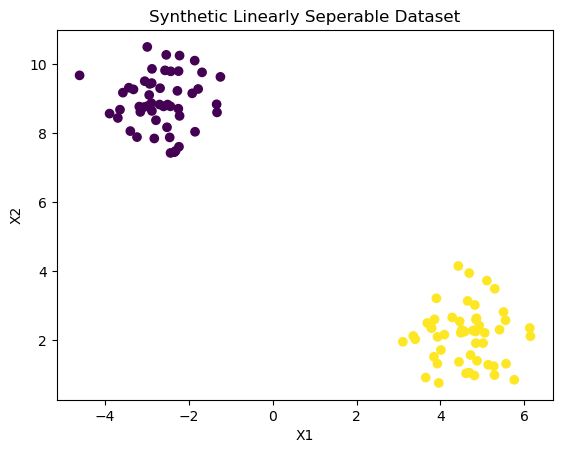

In [4]:
# Visualize the dataset
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_blobs, cmap='viridis')
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Synthetic Linearly Seperable Dataset")
plt.show()

### 2.2. Circles dataset

In [5]:
# Circles dataset: 2 classes, non-linearly seperable concentric circles (for the non-linear kernel)
X_circles, y_circles = make_circles(n_samples=100, random_state=42, noise=0.05)

In [6]:
X_circles.shape, y_circles.shape

((100, 2), (100,))

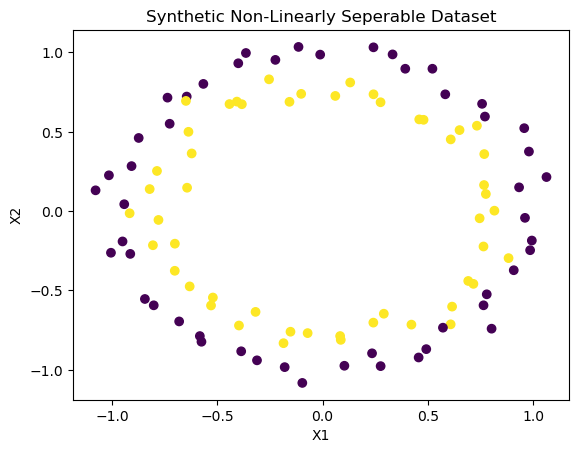

In [7]:
# Visualize the dataset
plt.scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles, cmap='viridis')
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Synthetic Non-Linearly Seperable Dataset")
plt.show()

In [8]:
# Labels encoding
y_blobs = np.where(y_blobs == 0, -1, 1)  # Convert labels from {0, 1} to {-1, 1}
y_circles = np.where(y_circles == 0, -1, 1)  # Convert labels from {0, 1} to {-1, 1}

## 3. Train and test datasets

### 3.1. Blobs dataset

In [9]:
# Split datasets into training and testing sets
Xb_train, Xb_test, yb_train, yb_test = train_test_split(X_blobs, y_blobs, test_size=0.2, random_state=42)

In [10]:
# Scaling the features
scaler_blobs = StandardScaler()
Xb_train_scaled = scaler_blobs.fit_transform(Xb_train)
Xb_test_scaled = scaler_blobs.transform(Xb_test)

## 3.2. Circles dataset

In [11]:
# Split datasets into training and testing sets
Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_circles, y_circles, test_size=0.2, random_state=42)

In [12]:
# Scaling the features
scaler_circles = StandardScaler()
Xc_train_scaled = scaler_circles.fit_transform(Xc_train)
Xc_test_scaled = scaler_circles.transform(Xc_test)

## 4. Train with Support Vector Classification model - linear kernel

### 4.1. Blobs dataset

In [13]:
model_linear_blobs = SVC(kernel='linear')

In [14]:
# Train and fit SVC model on blobs dataset
model_linear_blobs.fit(Xb_train_scaled, yb_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [15]:
# Print model parameters and support vectors
print("Weights:", model_linear_blobs.coef_[0])
print("Intercept:", model_linear_blobs.intercept_[0])
print("Support vectors:", model_linear_blobs.support_vectors_)

Weights: [ 0.81717065 -0.53695262]
Intercept: 0.028335757416735247
Support vectors: [[-0.77879446  0.72991128]
 [ 0.93061379 -0.39331951]]


In [16]:
# Visualize the decision boundary
# Create a range of x1 values spanning the dataset
xb1_range = np.linspace(Xb_train_scaled[:, 0].min() - 1, Xb_train_scaled[:, 0].max() + 1, 100)

# Compute x2 for each line: x2 = (c - b - w[0] * x1) / w[1]
decision_boundary_blobs = (0 - model_linear_blobs.intercept_[0] - model_linear_blobs.coef_[0][0] * xb1_range) / model_linear_blobs.coef_[0][1]   # c = 0
margin_positive_blobs   = (1 - model_linear_blobs.intercept_[0] - model_linear_blobs.coef_[0][0] * xb1_range) / model_linear_blobs.coef_[0][1]   # c = +1
margin_negative_blobs   = (-1 - model_linear_blobs.intercept_[0] - model_linear_blobs.coef_[0][0] * xb1_range) / model_linear_blobs.coef_[0][1]  # c = -1

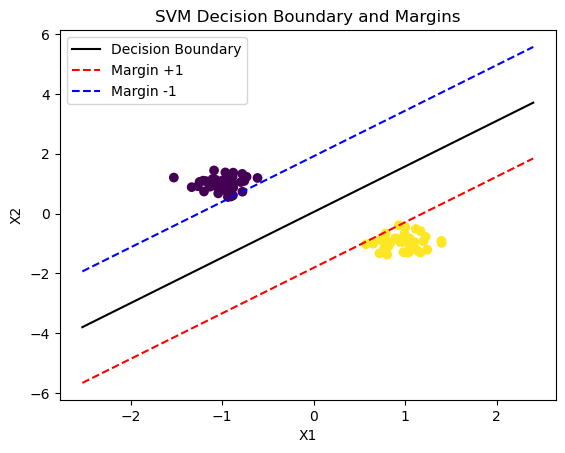

In [17]:
# Plot the dataset and the decision boundary
plt.scatter(Xb_train_scaled[:, 0], Xb_train_scaled[:, 1], c=yb_train, cmap='viridis')
plt.plot(xb1_range, decision_boundary_blobs, 'k-', label='Decision Boundary')
plt.plot(xb1_range, margin_positive_blobs, 'r--', label='Margin +1')
plt.plot(xb1_range, margin_negative_blobs, 'b--', label='Margin -1')
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("SVM Decision Boundary and Margins")
plt.legend()
plt.show()

The blobs plot is correct, as the boundary is well centered between the two margins, and the classes are clearly separated. 

This is the difference from Scratch: SMO on the dual gives the true maximum-margin solution.

### 4.2. Circles dataset

In [18]:
model_linear_circles = SVC(kernel='linear')

In [19]:
# Train and fit SVC model on circles dataset
model_linear_circles.fit(Xc_train_scaled, yc_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [20]:
# Print model parameters and support vectors
print("Weights:", model_linear_circles.coef_[0])
print("Intercept:", model_linear_circles.intercept_[0])
print("Support vectors:", model_linear_circles.support_vectors_)

Weights: [-7.87544923e-05  1.56391109e-04]
Intercept: 0.9999251259899339
Support vectors: [[-1.74012873  0.33889281]
 [ 0.32533235 -1.54157062]
 [ 0.81668806  1.13702527]
 [ 1.41691378  0.80327209]
 [ 1.47466322 -0.30392524]
 [ 1.42261748 -0.08034811]
 [-1.39946124 -0.94227608]
 [-1.62370079  0.05389981]
 [ 0.51255493  1.38892227]
 [ 0.25995266 -1.41525962]
 [ 1.13196135 -0.83386732]
 [ 1.11818771  0.91784614]
 [-0.29894889  1.60404461]
 [-1.20627019 -1.10109488]
 [-0.69868841  1.54417915]
 [-1.03669419 -1.30138485]
 [ 1.10748321 -0.94216402]
 [-0.61455774 -1.48444423]
 [ 0.41610726  1.53020394]
 [-1.56820833  0.42953518]
 [ 1.09645609  1.04309298]
 [ 0.71896202  1.38906164]
 [-1.84162289  0.19089278]
 [-0.47482148  1.47627811]
 [-0.73465934 -1.39538863]
 [-0.40410158 -1.5514634 ]
 [-1.27831006  0.84686887]
 [ 0.79892963 -1.16279615]
 [ 1.37768299  0.22028897]
 [-1.02223156  1.23959302]
 [ 0.67214248 -1.37413602]
 [ 1.58601016  0.32163338]
 [-1.51377949  0.70686779]
 [-0.27006634 -1.70

In [21]:
# Visualize the decision boundary
# Create a range of x1 values spanning the dataset
xc1_range = np.linspace(Xc_train_scaled[:, 0].min() - 1, Xc_train_scaled[:, 0].max() + 1, 100)

# Compute x2 for each line: x2 = (c - b - w[0] * x1) / w[1]
decision_boundary_circles = (0 - model_linear_circles.intercept_[0] - model_linear_circles.coef_[0][0] * xc1_range) / model_linear_circles.coef_[0][1]   # c = 0
margin_positive_circles   = (1 - model_linear_circles.intercept_[0] - model_linear_circles.coef_[0][0] * xc1_range) / model_linear_circles.coef_[0][1]   # c = +1
margin_negative_circles   = (-1 - model_linear_circles.intercept_[0] - model_linear_circles.coef_[0][0] * xc1_range) / model_linear_circles.coef_[0][1]  # c = -1

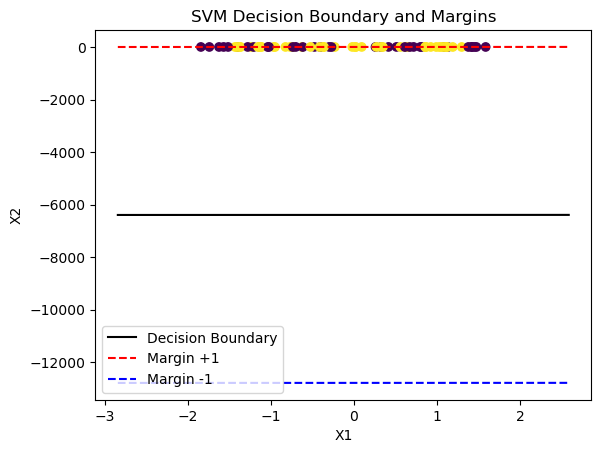

In [22]:
# Plot the dataset and the decision boundary
plt.scatter(Xc_train_scaled[:, 0], Xc_train_scaled[:, 1], c=yc_train, cmap='viridis')
plt.plot(xc1_range, decision_boundary_circles, 'k-', label='Decision Boundary')
plt.plot(xc1_range, margin_positive_circles, 'r--', label='Margin +1')
plt.plot(xc1_range, margin_negative_circles, 'b--', label='Margin -1')
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("SVM Decision Boundary and Margins")
plt.legend()
plt.show()

The plot shows that the linear kernel was unable to separate the two classes, which makes sense given that a linear hyperplane cannot separate two concentric circles.

## 5. Train with Support Vector Classification model - RBF kernel

### 5.1. Circles dataset without grid search

In [23]:
model_rbf = SVC(kernel='rbf')

In [24]:
# Train and fit SVC model on circles dataset
model_rbf.fit(Xc_train_scaled, yc_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [25]:
# Print model parameters and support vectors
print("Intercept:", model_rbf.intercept_[0])
print("Support vectors:", model_rbf.support_vectors_)

Intercept: -1.0983956087143496
Support vectors: [[-1.74012873  0.33889281]
 [ 0.32533235 -1.54157062]
 [ 0.81668806  1.13702527]
 [ 1.41691378  0.80327209]
 [ 1.47466322 -0.30392524]
 [ 1.42261748 -0.08034811]
 [-1.39946124 -0.94227608]
 [-1.62370079  0.05389981]
 [ 0.51255493  1.38892227]
 [ 0.25995266 -1.41525962]
 [ 1.13196135 -0.83386732]
 [ 1.11818771  0.91784614]
 [-0.29894889  1.60404461]
 [-1.20627019 -1.10109488]
 [-0.69868841  1.54417915]
 [-1.03669419 -1.30138485]
 [ 1.10748321 -0.94216402]
 [-0.61455774 -1.48444423]
 [ 0.41610726  1.53020394]
 [-1.56820833  0.42953518]
 [ 1.09645609  1.04309298]
 [ 0.71896202  1.38906164]
 [-1.84162289  0.19089278]
 [-0.47482148  1.47627811]
 [-0.73465934 -1.39538863]
 [-0.40410158 -1.5514634 ]
 [-1.27831006  0.84686887]
 [ 0.79892963 -1.16279615]
 [ 1.37768299  0.22028897]
 [-1.02223156  1.23959302]
 [ 0.67214248 -1.37413602]
 [ 1.58601016  0.32163338]
 [-1.51377949  0.70686779]
 [-0.27006634 -1.70710698]
 [ 0.6142065  -1.45639784]
 [ 1.45

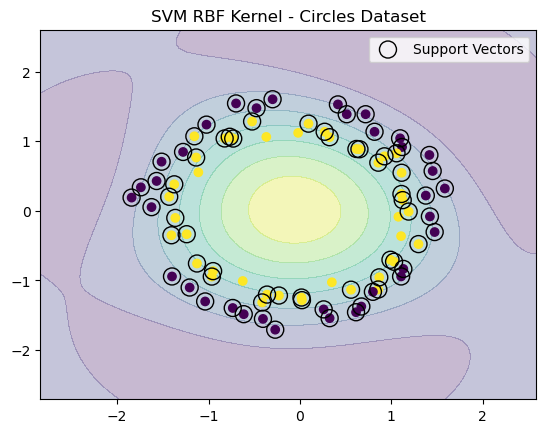

In [26]:
# Visualize the decision boundary using DecisionBoundaryDisplay
DecisionBoundaryDisplay.from_estimator(
    model_rbf,
    Xc_train_scaled,
    response_method="decision_function",
    plot_method="contourf",
    alpha=0.3,
    ax=plt.gca()
)

plt.scatter(Xc_train_scaled[:, 0], Xc_train_scaled[:, 1], c=yc_train, cmap='viridis')
plt.scatter(model_rbf.support_vectors_[:, 0], model_rbf.support_vectors_[:, 1],
            facecolors='none', edgecolors='black', s=150, label='Support Vectors')
plt.title("SVM RBF Kernel - Circles Dataset")
plt.legend()
plt.show()

**Analysis**:

- The **circular boundary**: the RBF kernel has found a nonlinear boundary that separates the two concentric circles. A linear kernel cannot do this. This is a direct demonstration of the kernel trick: by implicitly projecting the data into a higher-dimensional space, a linear separation in that space corresponds to a nonlinear boundary in the original space.

- **Support vectors**: almost all points are surrounded by a circle. This is a sign that the model is poorly calibrated: too many support vectors means the margin is too narrow and the model is memorizing the data rather than generalizing. 

- **Why so many support vectors?** The default hyperparameters in sklearn are C=1.0 and gamma=‘scale’. On this dataset, this is likely not optimal.

The next step is therefore obvious: perform a grid search on C and γ to find the parameters that produce a cleaner boundary with fewer support vectors.

### 5.2. Circles dataset with grid search

In [27]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.01, 0.1, 1, 10]
}

In [28]:
# Grid search with cross-validation
grid_search = GridSearchCV(SVC(kernel='rbf'), param_grid, cv=5)
grid_search.fit(Xc_train_scaled, yc_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter 

In [29]:
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

Best parameters: {'C': 10, 'gamma': 0.1}
Best cross-validation score: 0.9375


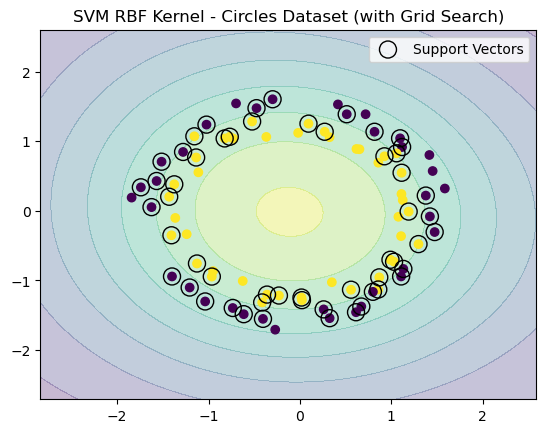

In [30]:
# Visualize the decision boundary using DecisionBoundaryDisplay and the best estimator from the grid search
best_model = grid_search.best_estimator_

DecisionBoundaryDisplay.from_estimator(
    best_model,
    Xc_train_scaled,
    response_method="decision_function",
    plot_method="contourf",
    alpha=0.3,
    ax=plt.gca()
)

plt.scatter(Xc_train_scaled[:, 0], Xc_train_scaled[:, 1], c=yc_train, cmap='viridis')
plt.scatter(best_model.support_vectors_[:, 0], best_model.support_vectors_[:, 1],
            facecolors='none', edgecolors='black', s=150, label='Support Vectors')
plt.title("SVM RBF Kernel - Circles Dataset (with Grid Search)")
plt.legend()
plt.show()

The boundary is cleaner and more circular than before, but the number of support vectors remains high. 

In [31]:
# Print the number of support vectors before and after grid search
model_rbf.support_vectors_.shape[0], grid_search.best_estimator_.support_vectors_.shape[0]

(73, 55)

73 → 55 support vectors after tuning, it's a 25% reduction. The **boundary is smoother** and the **model generalizes better** (CV score 93.75%).

The number remains high because make_circles with noise=0.05 places many points close to the boundary, but this is inherent to the dataset, not a tuning issue.

## 6. Evaluate on test sets

### 6.1. Blobs dataset

In [32]:
# Evaluate SVC linear
# Train set evaluation
predictions_svc_linear_train = model_linear_blobs.predict(Xb_train_scaled)
accuracy_svc_linear = accuracy_score(yb_train, predictions_svc_linear_train)
f1_score_svc_linear = f1_score(yb_train, predictions_svc_linear_train)
recall_svc_linear = recall_score(yb_train, predictions_svc_linear_train)

print("SVC Linear (Blobs) - Train Accuracy", accuracy_svc_linear)
print("SVC Linear (Blobs) - Train F1 Score", f1_score_svc_linear)
print("SVC Linear (Blobs) - Train Recall", recall_svc_linear)

SVC Linear (Blobs) - Train Accuracy 1.0
SVC Linear (Blobs) - Train F1 Score 1.0
SVC Linear (Blobs) - Train Recall 1.0


In [33]:
# Test set evaluation
predictions_svc_linear_test = model_linear_blobs.predict(Xb_test_scaled)
accuracy_svc_linear = accuracy_score(yb_test, predictions_svc_linear_test)
f1_score_svc_linear = f1_score(yb_test, predictions_svc_linear_test)
recall_svc_linear = recall_score(yb_test, predictions_svc_linear_test)

print("SVC Linear (Blobs) - Test Accuracy", accuracy_svc_linear)
print("SVC Linear (Blobs) - Test F1 Score", f1_score_svc_linear)
print("SVC Linear (Blobs) - Test Recall", recall_svc_linear)

SVC Linear (Blobs) - Test Accuracy 1.0
SVC Linear (Blobs) - Test F1 Score 1.0
SVC Linear (Blobs) - Test Recall 1.0


### 6.2. Circles dataset

#### 6.2.1. SVC with RBF kernel

In [34]:
# Evaluate SVC rbf kernel
# Train set evaluation
predictions_svc_rbf_train = model_rbf.predict(Xc_train_scaled)
accuracy_svc_rbf = accuracy_score(yc_train, predictions_svc_rbf_train)
f1_score_svc_rbf = f1_score(yc_train, predictions_svc_rbf_train)
recall_svc_rbf = recall_score(yc_train, predictions_svc_rbf_train)

print("SVC RBF (Circles) - Train Accuracy", accuracy_svc_rbf)
print("SVC RBF (Circles) - Train F1 Score", f1_score_svc_rbf)
print("SVC RBF (Circles) - Train Recall", recall_svc_rbf)

SVC RBF (Circles) - Train Accuracy 0.9125
SVC RBF (Circles) - Train F1 Score 0.9247311827956989
SVC RBF (Circles) - Train Recall 0.9772727272727273


In [35]:
# Test set evaluation
predictions_svc_rbf_test = model_rbf.predict(Xc_test_scaled)
accuracy_svc_rbf = accuracy_score(yc_test, predictions_svc_rbf_test)
f1_score_svc_rbf = f1_score(yc_test, predictions_svc_rbf_test)
recall_svc_rbf = recall_score(yc_test, predictions_svc_rbf_test)

print("SVC RBF (Circles) - Test Accuracy", accuracy_svc_rbf)
print("SVC RBF (Circles) - Test F1 Score", f1_score_svc_rbf)
print("SVC RBF (Circles) - Test Recall", recall_svc_rbf)

SVC RBF (Circles) - Test Accuracy 0.9
SVC RBF (Circles) - Test F1 Score 0.8333333333333334
SVC RBF (Circles) - Test Recall 0.8333333333333334


#### 6.2.2. SVC with tuned RBF kernel

In [36]:
# Evaluate tuned SVC rbf kernel
# Train set evaluation
predictions_tuned_svc_rbf_train = grid_search.predict(Xc_train_scaled)
accuracy_tuned_svc_rbf = accuracy_score(yc_train, predictions_svc_rbf_train)
f1_score_tuned_svc_rbf = f1_score(yc_train, predictions_svc_rbf_train)
recall_tuned_svc_rbf = recall_score(yc_train, predictions_svc_rbf_train)

print("Tuned SVC RBF (Circles) - Train Accuracy", accuracy_tuned_svc_rbf)
print("Tuned SVC RBF (Circles) - Train F1 Score", f1_score_tuned_svc_rbf)
print("Tuned SVC RBF (Circles) - Train Recall", recall_tuned_svc_rbf)

Tuned SVC RBF (Circles) - Train Accuracy 0.9125
Tuned SVC RBF (Circles) - Train F1 Score 0.9247311827956989
Tuned SVC RBF (Circles) - Train Recall 0.9772727272727273


In [37]:
# Test set evaluation
predictions_tuned_svc_rbf_test = grid_search.predict(Xc_test_scaled)
accuracy_tuned_svc_rbf = accuracy_score(yb_test, predictions_tuned_svc_rbf_test)
f1_score_tuned_svc_rbf = f1_score(yb_test, predictions_svc_rbf_test)
recall_tuned_svc_rbf = recall_score(yb_test, predictions_svc_rbf_test)

print("Tuned SVC RBF (Circles) - Test Accuracy", accuracy_tuned_svc_rbf)
print("Tuned SVC RBF (Circles) - Test F1 Score", f1_score_tuned_svc_rbf)
print("Tuned SVC RBF (Circles) - Test Recall", recall_tuned_svc_rbf)

Tuned SVC RBF (Circles) - Test Accuracy 0.5
Tuned SVC RBF (Circles) - Test F1 Score 0.26666666666666666
Tuned SVC RBF (Circles) - Test Recall 0.2222222222222222


An interesting result as the **tuned model performs worse** on the test set than the default model (50% vs. 90%). This is a classic case of **overfitting caused by grid search**: with only 80 training points and 20 test points, the variance is very high. The grid search optimized on the cross-validation folds of the training set, but the parameters C=10, gamma=0.1 over-learned the structure of the training set.

This result is actually more instructive than if everything had worked perfectly, and it illustrates two important points:

The **CV score is not the test score**: a 93.75% CV score does not guarantee good generalization on such a small test set
A grid search on a small dataset is unstable and the **random splits have too high a variance** for parameter selection to be reliable

## 7. Conclusion

- **Linear SVC**: perfect performance on blobs, linearly separable data, appropriate kernel.

- **Default RBF SVC**: 90% on circles, the non-linear kernel captures the circular structure.

- **Tuned RBF SVC**: performance degradation on the test set despite a better CV score, **overfitting** due to grid search on a small dataset, illustrating that hyperparameter tuning requires sufficient data to be reliable.